<a href="https://colab.research.google.com/github/hania-sajjad/Week-2-Task/blob/main/week2_baseline_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#IMPORT LIBRARIES
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Model selection
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

# Regression models
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Evaluation metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# UPLOAD DATASET
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Load the Engineered Dataset

The engineered dataset created during exploratory data analysis is loaded for regression modeling.

In [3]:
file_path = "/content/drive/MyDrive/Week2Data/steel_energy_engineered.csv"

df = pd.read_csv(file_path)

df.head()

,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type,Hour,Day_Name,Month,Day_Type,Power_Factor_Ratio,High_Load
0,2018-01-01 00:15:00,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load,0,Monday,1,Weekday,1.365934,0
1,2018-01-01 00:30:00,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load,0,Monday,1,Weekday,1.497679,0
2,2018-01-01 00:45:00,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load,0,Monday,1,Weekday,1.422880,0
3,2018-01-01 01:00:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load,1,Monday,1,Weekday,1.468644,0
4,2018-01-01 01:15:00,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load,1,Monday,1,Weekday,1.545117,0


In [4]:
# VERIFICATION
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 17 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   date                                  35040 non-null  object 
 1   Usage_kWh                             35040 non-null  float64
 2   Lagging_Current_Reactive.Power_kVarh  35040 non-null  float64
 3   Leading_Current_Reactive_Power_kVarh  35040 non-null  float64
 4   CO2(tCO2)                             35040 non-null  float64
 5   Lagging_Current_Power_Factor          35040 non-null  float64
 6   Leading_Current_Power_Factor          35040 non-null  float64
 7   NSM                                   35040 non-null  int64  
 8   WeekStatus                            35040 non-null  object 
 9   Day_of_week                           35040 non-null  object 
 10  Load_Type                             35040 non-null  object 
 11  Hour           

## Remove Target Leakage

The original `date` column is removed because its information has already been extracted into separate time-based features. The engineered `High_Load` feature is also removed because it was created directly from the target variable (`Usage_kWh`), which would introduce target leakage. Additionally, `CO2(tCO2)` is excluded because it is derived from energy consumption and would unfairly improve model performance.

In [5]:
df = df.drop(columns=[
    'date',
    'CO2(tCO2)',
    'High_Load'
], errors='ignore')

df.head()

,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type,Hour,Day_Name,Month,Day_Type,Power_Factor_Ratio
0,3.17,2.95,0.0,73.21,100.0,900,Weekday,Monday,Light_Load,0,Monday,1,Weekday,1.365934
1,4.00,4.46,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load,0,Monday,1,Weekday,1.497679
2,3.24,3.28,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load,0,Monday,1,Weekday,1.422880
3,3.31,3.56,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load,1,Monday,1,Weekday,1.468644
4,3.82,4.50,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load,1,Monday,1,Weekday,1.545117


In [17]:
print("Missing values in df:", df.isnull().sum().sum())
print("Shape:", df.shape)

Missing values in df: 0
Shape: (35040, 25)


## Encode Categorical Variables

Machine learning algorithms require numerical input features. Therefore, categorical variables are converted into numerical representations using **One-Hot Encoding**. This method creates separate binary columns for each category without introducing any artificial ordering, making it well-suited for nominal categorical features.

In [6]:
# Check categorical columns
df.select_dtypes(include='object').columns

Index(['WeekStatus', 'Day_of_week', 'Load_Type', 'Day_Name', 'Day_Type'], dtype='object')

In [7]:
df = pd.get_dummies(
    df,
    columns=[
        'WeekStatus',
        'Day_of_week',
        'Load_Type',
        'Day_Name',
        'Day_Type'
    ],
    drop_first=True
)

In [8]:
# VERIFICATION
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 25 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Usage_kWh                             35040 non-null  float64
 1   Lagging_Current_Reactive.Power_kVarh  35040 non-null  float64
 2   Leading_Current_Reactive_Power_kVarh  35040 non-null  float64
 3   Lagging_Current_Power_Factor          35040 non-null  float64
 4   Leading_Current_Power_Factor          35040 non-null  float64
 5   NSM                                   35040 non-null  int64  
 6   Hour                                  35040 non-null  int64  
 7   Month                                 35040 non-null  int64  
 8   Power_Factor_Ratio                    35039 non-null  float64
 9   WeekStatus_Weekend                    35040 non-null  bool   
 10  Day_of_week_Monday                    35040 non-null  bool   
 11  Day_of_week_Sat

## Separate Features and Target

The target variable (`Usage_kWh`) is separated from the predictor variables. The remaining columns are used as input features for training the regression models.

In [18]:
X = df.drop(columns='Usage_kWh')
y = df['Usage_kWh']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (35040, 24)
Target shape: (35040,)


In [19]:
print("Missing values in X:", X.isnull().sum().sum())
print(X.isnull().sum()[X.isnull().sum() > 0])

Missing values in X: 0
Series([], dtype: int64)


## Train-Test Split

The dataset is divided into training (80%) and testing (20%) sets using `random_state=42` to ensure reproducibility. The training data is used to fit the models, while the testing data is reserved for evaluating their predictive performance.

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Missing values in X_train:", X_train.isnull().sum().sum())

print("Training Features:", X_train.shape)
print("Testing Features :", X_test.shape)

print("Training Target :", y_train.shape)
print("Testing Target  :", y_test.shape)

Missing values in X_train: 0
Training Features: (28032, 24)
Testing Features : (7008, 24)
Training Target : (28032,)
Testing Target  : (7008,)


## Train Regression Models

Four regression algorithms are trained on the training dataset to establish baseline performance. These models include Linear Regression, Ridge Regression, Decision Tree Regressor, and Random Forest Regressor.

In [21]:
# Create regression models
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42
    )
}

## Model Evaluation

Each model is trained using the training dataset and evaluated on the testing dataset using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R-squared (R²).

In [22]:
# MISSING VALUE HANDLING
# Count missing values in each column
missing = df.isnull().sum()

# Show only columns with missing values
missing[missing > 0]

# Fill missing value in Power_Factor_Ratio with its median
df['Power_Factor_Ratio'] = df['Power_Factor_Ratio'].fillna(
    df['Power_Factor_Ratio'].median()
)

df.isnull().sum().sum()

np.int64(0)

In [23]:
# Total number of missing values
print("Total missing values:", X.isnull().sum().sum())

# Show columns that still have missing values
print(X.isnull().sum()[X.isnull().sum() > 0])

X[X.isnull().any(axis=1)]

Total missing values: 0
Series([], dtype: int64)


,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,Hour,Month,Power_Factor_Ratio,WeekStatus_Weekend,Day_of_week_Monday,...,Day_of_week_Wednesday,Load_Type_Maximum_Load,Load_Type_Medium_Load,Day_Name_Monday,Day_Name_Saturday,Day_Name_Sunday,Day_Name_Thursday,Day_Name_Tuesday,Day_Name_Wednesday,Day_Type_Weekend


In [31]:
# Convert boolean columns to integers (0 and 1)
bool_cols = X_train.select_dtypes(include='bool').columns

X_train[bool_cols] = X_train[bool_cols].astype(int)
X_test[bool_cols] = X_test[bool_cols].astype(int)

In [32]:
results = []

for name, model in models.items():

    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Metrics
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    })

    print(f"\n{name}")
    print(f"MAE: {mae:.3f}")
    print(f"RMSE: {rmse:.3f}")
    print(f"R²: {r2:.3f}")


Linear Regression
MAE: 5.622
RMSE: 8.013
R²: 0.944

Ridge Regression
MAE: 5.615
RMSE: 8.013
R²: 0.944

Decision Tree
MAE: 0.554
RMSE: 1.463
R²: 0.998

Random Forest
MAE: 0.287
RMSE: 0.878
R²: 0.999


In [34]:
results_df = pd.DataFrame(
    results,
    columns=["Model", "MAE", "RMSE", "R2 Score"]
)

results_df

,Model,MAE,RMSE,R2 Score
0,Linear Regression,5.621509,8.012634,0.943520
1,Ridge Regression,5.615074,8.013126,0.943513
2,Decision Tree,0.553991,1.463486,0.998116
3,Random Forest,0.286714,0.878173,0.999322


 ## 5-Fold Cross Validation

To obtain a more reliable estimate of model performance, 5-fold cross-validation is performed. The dataset is divided into five folds, where each fold is used once as the validation set while the remaining folds are used for training. The mean RMSE across all folds is reported for each model.

In [33]:
cv_results = []

for name, model in models.items():

    scores = cross_val_score(
        model,
        X,
        y,
        cv=5,
        scoring='neg_root_mean_squared_error'
    )

    mean_rmse = -scores.mean()

    cv_results.append([name, mean_rmse])

    print(f"{name}: Mean CV RMSE = {mean_rmse:.3f}")

Linear Regression: Mean CV RMSE = 8.487
Ridge Regression: Mean CV RMSE = 8.476
Decision Tree: Mean CV RMSE = 2.093
Random Forest: Mean CV RMSE = 1.341


## Comparison of Test RMSE

A bar chart is created to compare the Root Mean Squared Error (RMSE) of all four regression models on the testing dataset. Lower RMSE indicates better predictive performance.

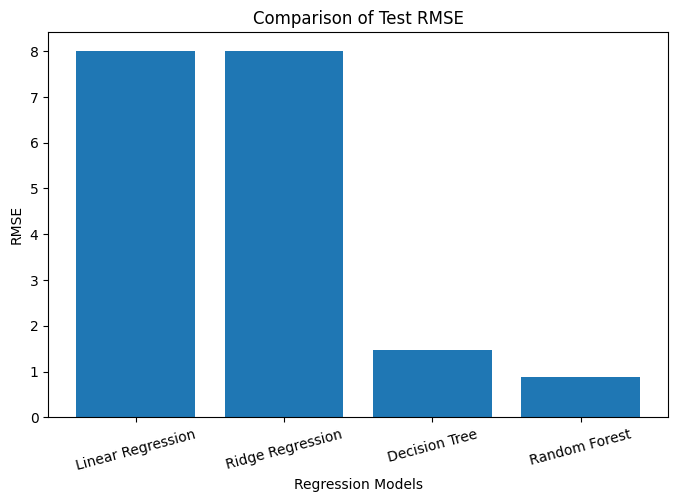

In [35]:
plt.figure(figsize=(8,5))

plt.bar(results_df["Model"], results_df["RMSE"])

plt.title("Comparison of Test RMSE")
plt.xlabel("Regression Models")
plt.ylabel("RMSE")

plt.xticks(rotation=15)

plt.show()